In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#World Constants
g = 9.81


In [12]:
# Rider Parameters
m = 75 #Total mass in KG of rider and bike
CdA = 0.26 # Cd= drag coefficent, A = frontal area
P_output = 200 #Power output in watts (const only for now)

#Rider Power Parameters
P_max = 400
P_threshold = 300 #Above this power threshold fatigue will build
P_base = 250 #Default power output on flat ground

hill_factor = 800 #How much does rider change power output due to hills

fatigue_rate = 0.4 #how fast fatigue builds when rider is above threshold
recovery_rate = 0.1 #how fast fatigue recovers when below threshold
fatigue_impact = 0.4 #How much fatigue reduces max power


In [13]:
# Course Segment Inputs
a_density = 1.225 #Air density
hw = 1.0 #Headwind in m/s
grad = 0.03 #Steepness of course in degress from flat (pos = uphill, neg = downhill)
total_distance = 2000.0 #Distance of course in meters

In [14]:
#Trial Assumptions
dt = 0.05 #Timesteps

In [25]:
v = 0 #Starting speed = 0
dist = 0.0 #Starting Distance = 0
t = 0 #Starting time = 0
fatigue = 0 #starting fatigue = 0

times = []
speeds = []
distances = []
drags = []
fatigues = []


while dist < total_distance:
    P_target =  P_base + hill_factor * grad
    P_cap = P_max * (1 - fatigue_impact * fatigue)
    P_output = min(P_target, P_cap)

    if P_output > P_threshold:
        fatigue = fatigue + fatigue_rate * dt
    else:
        fatigue = max(0, fatigue - recovery_rate * dt)
        
    Rider_force_output = P_output / max(v, 0.05) # power = force * velocity, so force = power/velocity, max is to prevent the divide by 0 
                                                 # since rider starts from rest
    drag = 0.5 * a_density * CdA * ((v + hw)**2)
    gravity = m * g * np.sin(grad)

    Rider_Net_force = Rider_force_output - drag - gravity

    v = max(0, v + ((dt/m) * Rider_Net_force))
    dist = dist + v *dt
    t = t + dt

    times.append(t)
    speeds.append(v)
    distances.append(dist)
    drags.append(drag)

[]

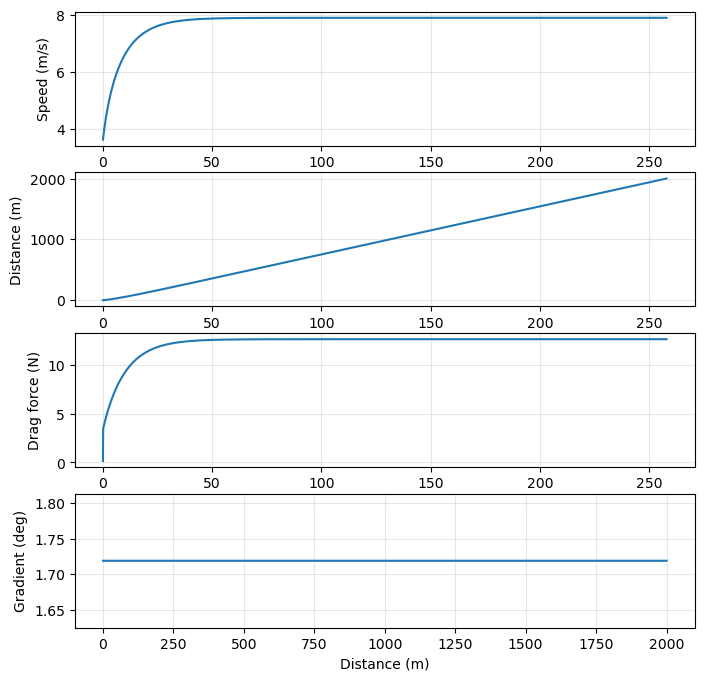

In [24]:
fig, ax = plt.subplots(4,1, figsize=(8,8))

ax[0].plot(times, speeds)
ax[0].set_ylabel("Speed (m/s)")
ax[0].set_xlabel("Time (s)")
ax[0].grid(alpha=0.3)
 
ax[1].plot(times, distances)
ax[1].set_ylabel("Distance (m)")
ax[1].set_xlabel("Time (s)")
ax[1].grid(alpha=0.3)
 
ax[2].plot(times, drags)
ax[2].set_ylabel("Drag force (N)")
ax[2].set_xlabel("Time (s)")
ax[2].grid(alpha=0.3)

ax[3].plot(distances, [np.degrees(grad)]*len(distances))
ax[3].set_ylabel("Gradient (deg)")
ax[3].set_xlabel("Distance (m)")
ax[3].grid(alpha=0.3)

plt.plot()